In [2]:
# Consolidated imports and device setup
import os, time, copy, random
from io import BytesIO
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
import requests

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import models, transforms
from torchvision.datasets import ImageFolder

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device ->', device)

Device -> cpu


In [ ]:
# Dataset path and quick exploration
DATA_ROOT = '../data/dataset/archive/original'
assert os.path.isdir(DATA_ROOT), f'Dataset path not found: {DATA_ROOT}'

def count_images(path):
    return {c: len(os.listdir(os.path.join(path, c))) for c in os.listdir(path)}

class_counts = count_images(DATA_ROOT)
print('Classes found:', list(class_counts.keys()))

def sample_image_sizes(path, per_class=50):
    shapes = []
    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        for img_file in os.listdir(cls_path)[:per_class]:
            pth = os.path.join(cls_path, img_file)
            with Image.open(pth) as im: shapes.append(im.size)
    return shapes

shapes = sample_image_sizes(DATA_ROOT, per_class=50)
if shapes:
    w,h = zip(*shapes)
    print(f'Avg size: {np.mean(w):.1f}x{np.mean(h):.1f} | Min: {np.min(w)}x{np.min(h)} | Max: {np.max(w)}x{np.max(h)}')


AssertionError: Dataset path not found: ../../data/dataset/archive/original

In [ ]:
# Transforms, dataset and dataloaders
IMG_SIZE = 224
def get_transforms(img_size=IMG_SIZE):
    train_t = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
    ])
    val_t = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])
    return train_t, val_t

train_t, val_t = get_transforms()
dataset = ImageFolder(root=DATA_ROOT, transform=train_t)
class_names = dataset.classes
print('class_names ->', class_names)

train_n = int(0.7 * len(dataset))
val_n = int(0.2 * len(dataset))
test_n = len(dataset) - train_n - val_n
train_ds, val_ds, test_ds = random_split(dataset, [train_n, val_n, test_n], generator=torch.Generator().manual_seed(42))
val_ds.dataset.transform = val_t
test_ds.dataset.transform = val_t
BATCH = 32
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=4)


class_names -> ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [ ]:
# Model creation and training setup
def make_resnet50(num_classes):
    m = models.resnet50(pretrained=True)
    for p in m.parameters(): p.requires_grad = False
    nf = m.fc.in_features
    m.fc = nn.Sequential(nn.Linear(nf, 512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, num_classes))
    return m.to(device)

NUM_CLASSES = len(class_names)
model = make_resnet50(NUM_CLASSES)
print('Model ready with', NUM_CLASSES, 'classes')

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-4)


/Users/mihai/Developer/garbage-optimizer/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/mihai/Developer/garbage-optimizer/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model ready with 10 classes


In [ ]:
# Training loop (preserves original behavior)
def train(model, tr_loader, vl_loader, criterion, optimizer, device, epochs=5):
    best_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    start = time.time()
    for epoch in range(epochs):
        print(f'\nEpoch {epoch+1}/{epochs}')
        for phase in ('train','val'):
            if phase == 'train': model.train(); loader = tr_loader
            else: model.eval(); loader = vl_loader

            running_loss = 0.0; running_corrects = 0
            for X,y in tqdm(loader, desc=f'{phase} loop', leave=False):
                X, y = X.to(device), y.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase=='train'):
                    out = model(X)
                    _, preds = torch.max(out,1)
                    loss = criterion(out, y)
                    if phase == 'train': loss.backward(); optimizer.step()
                running_loss += loss.item() * X.size(0)
                running_corrects += torch.sum(preds==y.data)

            epoch_loss = running_loss / len(loader.dataset)
            epoch_acc = running_corrects.double() / len(loader.dataset)
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            if phase=='val' and epoch_acc>best_acc: best_acc = epoch_acc; best_wts = copy.deepcopy(model.state_dict())
    elapsed = time.time()-start; print(f'Finished in {elapsed//60:.0f}m {elapsed%60:.0f}s | Best val Acc: {best_acc:.4f}')
    model.load_state_dict(best_wts)
    return model

# Execute training (default 5 epochs
model = train(model, train_loader, val_loader, criterion, optimizer, device, epochs=0)



Epoch 1/10


train Loss: 0.9868 Acc: 0.7317


val Loss: 0.4980 Acc: 0.8548

Epoch 2/10


train Loss: 0.4701 Acc: 0.8575


val Loss: 0.3770 Acc: 0.8825

Epoch 3/10


...

val Loss: 0.2795 Acc: 0.9094

Epoch 9/10


train Loss: 0.2692 Acc: 0.9102


val Loss: 0.2737 Acc: 0.9082

Epoch 10/10


train Loss: 0.2630 Acc: 0.9108


val Loss: 0.2775 Acc: 0.9086
Finished in 136m 18s | Best val Acc: 0.9094


Accuracy: 0.9063 Precision: 0.9074 Recall: 0.9063 F1: 0.9061
              precision    recall  f1-score   support

     battery       0.95      0.97      0.96        75
  biological       0.93      0.97      0.95        68
   cardboard       0.85      0.89      0.87       117
     clothes       0.99      0.97      0.98       191
       glass       0.93      0.85      0.89       202
       metal       0.81      0.87      0.84        95
       paper       0.86      0.92      0.89       130
     plastic       0.86      0.84      0.85       148
       shoes       0.97      0.98      0.98       153
       trash       0.81      0.73      0.77        48

    accuracy                           0.91      1227
   macro avg       0.90      0.90      0.90      1227
weighted avg       0.91      0.91      0.91      1227



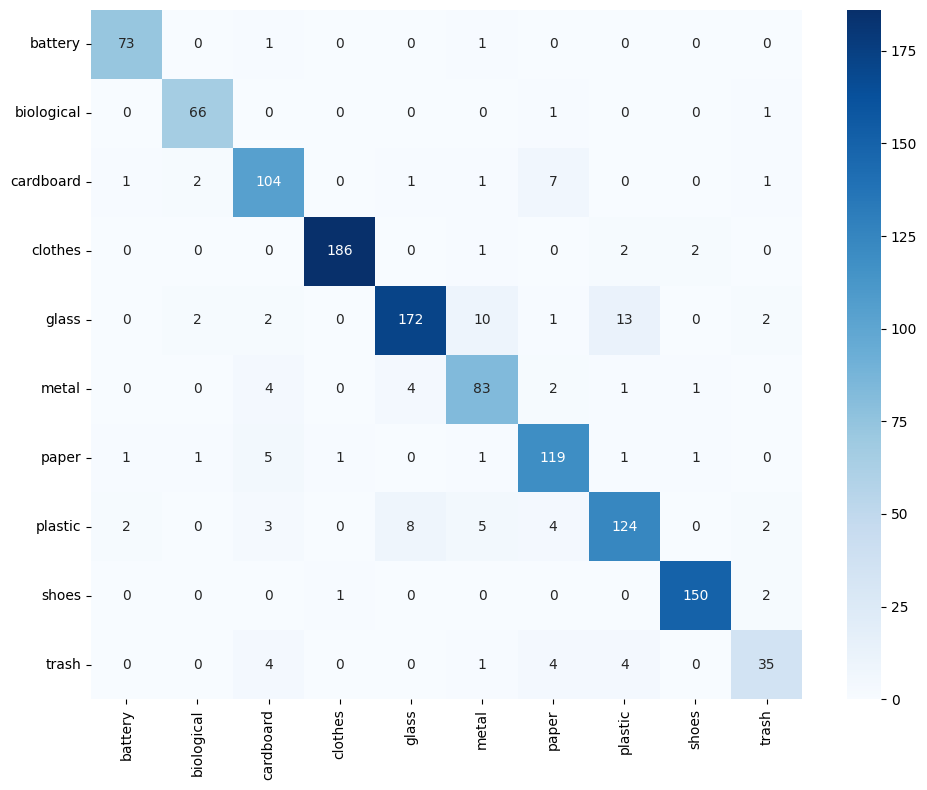

In [ ]:
# Evaluation and metrics
def evaluate(model, loader, device, class_names=None, save_cm=False, out_path='confusion_matrix.png'):
    model.eval(); preds=[]; labels=[]
    with torch.no_grad():
        for X,y in tqdm(loader, desc='Evaluating', leave=False):
            X,y = X.to(device), y.to(device)
            out = model(X); _, p = torch.max(out,1)
            preds.extend(p.cpu().numpy()); labels.extend(y.cpu().numpy())
    preds = np.array(preds); labels = np.array(labels)
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average='weighted', zero_division=0)
    rec = recall_score(labels, preds, average='weighted', zero_division=0)
    f1 = f1_score(labels, preds, average='weighted', zero_division=0)
    print(f'Accuracy: {acc:.4f} Precision: {prec:.4f} Recall: {rec:.4f} F1: {f1:.4f}')
    print(classification_report(labels, preds, target_names=class_names if class_names else None))
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(10,8)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names); plt.tight_layout();
    if save_cm: plt.savefig(out_path, dpi=300); print('Saved CM ->', out_path)
    plt.show()

# Run evaluation on test set
evaluate(model, test_loader, device, class_names=class_names, save_cm=False)


In [ ]:
# Save model and URL inference helper
torch.save(model, '../models/model.pth')

def predict_from_url(model, url, device, class_names, img_size=IMG_SIZE):
    tf = transforms.Compose([transforms.Resize((img_size, img_size)), transforms.ToTensor()])
    resp = requests.get(url)
    img = Image.open(BytesIO(resp.content)).convert('RGB')
    inp = tf(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad(): out = model(inp); _, p = torch.max(out,1); cls = class_names[p.item()]
    plt.imshow(img); plt.axis('off'); plt.title(f'Predicted: {cls}'); plt.show()
    return cls

# Example URL test (keeps the same sample URL)
test_url = 'https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fthf.bing.com%2Fth%2Fid%2FOIP.TnOUhAy6LSYHKY_Bv0154AHaDc%3Fcb%3Dthfc1%26pid%3DApi&f=1&ipt=9ea99d9f106d5524c748cc0477e1561fae8b06c13e4c77103226ccff22e1a8f3&ipo=images'
pred = predict_from_url(model, test_url, device, class_names)
print('Predicted Class:', pred)


NameError: name 'torch' is not defined